In [34]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
from torch.utils.data import TensorDataset, DataLoader

In [3]:
#display plots directly inside the notebook output cell instead of opening a separate window.
%matplotlib inline

In [10]:


path = "../data/cifar-10-batches-py"

def load_batch(filename):
    with open(filename, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')

    images = batch[b'data']
    labels = batch[b'labels']

    images = images.reshape(-1,3,32,32)
    images = images.transpose(0,2,3,1)  # convert to HWC

    return images, labels

In [44]:
X_train = []
y_train = []

for i in range(1,6):
    images, labels = load_batch(os.path.join(path, f"data_batch_{i}"))

    X_train.append(images)
    y_train.extend(labels)

X_train = np.concatenate(X_train)
y_train = np.array(y_train)

In [12]:
#Load Test Data
X_test, y_test = load_batch(os.path.join(path, "test_batch"))
y_test = np.array(y_test)

In [13]:
#check shapes
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


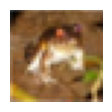

In [20]:
#Display an image
plt.figure(figsize=(1.2,1.2))   # smaller figure
plt.imshow(X_train[0])
plt.axis("off")
plt.show()


In [27]:
#CIFAR-10 CLASS NAMES
classes = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

print(classes[y_train[49999]])

automobile


In [28]:
#we create tensors from numpy vectors and normalize for faster  training and more stably when inputs are small
X_train_t = torch.from_numpy(X_train).float() / 255.0   # (N,32,32,3)
y_train_t = torch.from_numpy(y_train).long()

X_test_t  = torch.from_numpy(X_test).float() / 255.0
y_test_t  = torch.from_numpy(y_test).long()

In [32]:
'''DataLoader
✔ splits data into batches
✔ shuffles data each epoch
✔ loads data efficiently
✔ feeds batches to the model#'''
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)

In [36]:
#Define ANN ( Flatten+Dense+ReLU+Dense+ReLU+Dense
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                 # (32,32,3) -> 3072
            nn.Linear(32*32*3, 3000),
            nn.ReLU(),
            nn.Linear(3000, 1000),
            nn.ReLU(),
            nn.Linear(1000, 10)           # logits for 10 classes
        )

    def forward(self, x):
        return self.net(x)

In [37]:
#create the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ANN().to(device)

In [38]:
#Loss+Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [39]:
#tranining Loop
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} | loss={train_loss:.4f} | acc={train_acc:.4f}")

Epoch 1/5 | loss=2.1632 | acc=0.2264
Epoch 2/5 | loss=1.9611 | acc=0.3090
Epoch 3/5 | loss=1.8766 | acc=0.3403
Epoch 4/5 | loss=1.8245 | acc=0.3594
Epoch 5/5 | loss=1.7811 | acc=0.3741


In [40]:
#evaluate on test set
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

print("Test accuracy:", correct / total)

Test accuracy: 0.3745


In [52]:
X_train_t = torch.from_numpy(X_train).float() / 255.0   # (N,32,32,3)
y_train_t = torch.from_numpy(y_train).long()

X_test_t  = torch.from_numpy(X_test).float() / 255.0
y_test_t  = torch.from_numpy(y_test).long()

In [61]:
# permute() reorders the dimensions of a tensor.
X_train_t = X_train_t.permute(0, 3, 1, 2)
X_test_t  = X_test_t.permute(0, 3, 1, 2)

In [54]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)

In [55]:
import torch


class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Shape math (with padding=0):
        # Input: 3x32x32
        # Conv3x3 -> 32x30x30
        # Pool2 -> 32x15x15
        # Conv3x3 -> 64x13x13
        # Pool2 -> 64x6x6
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 6 * 6, 64),
            nn.ReLU(),
            nn.Linear(64, 10)  # logits
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [56]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CIFAR_CNN().to(device)

criterion = nn.CrossEntropyLoss()                 # sparse_categorical_crossentropy equivalent
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # adam

In [58]:
#Quick sanity check for shape (highly recommended)Before training
#PyTorch convolution expects torch.Size([128, 3, 32, 32])
xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([128, 3, 32, 32]) torch.Size([128])


In [63]:
def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            preds = outputs.argmax(dim=1)

            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return correct / total

In [65]:
#Minimal TRAINING LOOP
epochs = 5

for epoch in range(epochs):

    model.train()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

    train_acc = evaluate_accuracy(model, train_loader, device)
    test_acc  = evaluate_accuracy(model, test_loader, device)

    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f} test_acc={test_acc:.4f}")


Epoch 1: train_acc=0.7119 test_acc=0.6667
Epoch 2: train_acc=0.7164 test_acc=0.6688
Epoch 3: train_acc=0.7247 test_acc=0.6754
Epoch 4: train_acc=0.7336 test_acc=0.6822
Epoch 5: train_acc=0.7477 test_acc=0.6883


In [62]:
#EVluate on test set
import torch

def evaluate_accuracy(model, data_loader, device="cpu"):
    model.eval()  # important: turns off dropout, uses running stats for batchnorm
    correct = 0
    total = 0

    with torch.no_grad():  # no gradients during evaluation
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)                 # (B,10)
            preds = logits.argmax(dim=1)       # predicted class index
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return correct / total

test_acc = evaluate_accuracy(model, test_loader, device)
print("Test accuracy:", test_acc)

Test accuracy: 0.6203
